In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "pandas", "numpy", "matplotlib", "seaborn",
    "statsmodels", "scipy", "scikit-learn"], check=False)
print("Dependencies ready.")

Dependencies ready.


In [2]:
import glob, json, os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import mixedlm, ols, logit
from statsmodels.stats.anova import anova_lm

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK.")

Imports OK.


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
REPO_ROOT = os.path.abspath(os.path.join(_NOTEBOOK_DIR, ".."))
if not os.path.isdir(os.path.join(REPO_ROOT, "data-exports")):
    REPO_ROOT = os.path.abspath(".")
if not os.path.isdir(os.path.join(REPO_ROOT, "data-exports")):
    REPO_ROOT = os.path.abspath("..")

_candidates = sorted(glob.glob(os.path.join(
    REPO_ROOT, "data-exports", "*", "moderation_sessions_export_*.csv")))
if _candidates:
    DATA_DIR = os.path.dirname(_candidates[-1])
elif glob.glob("moderation_sessions_export_*.csv"):
    DATA_DIR = "."
else:
    raise FileNotFoundError("No moderation_sessions_export_*.csv found.")

_mod_files = sorted(glob.glob(os.path.join(DATA_DIR, "moderation_sessions_export_*.csv")))
EXPORT_TIMESTAMP = _mod_files[-1].split("_export_")[1].replace(".csv", "")
SCENARIOS_JSON   = os.path.join(REPO_ROOT, "scenarios", "pilot_scenarios.json")
MODEL_STRATEGY_FILE   = os.path.join(DATA_DIR, "model_strategy_for_notebook.csv")
PARENT_MOTIVATION_FILE = os.path.join(DATA_DIR, "parent_motivation_for_notebook.csv")
OUTPUT_DIR = os.path.join(DATA_DIR, "highlight_analysis_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEV_MODE = False
ALPHA    = 0.05
VALENCE_POSITIVE_THRESHOLD = 5
VALENCE_NEGATIVE_THRESHOLD = 3
EQUIVALENCE_BOUND   = 0.5
MIN_OBS_FOR_MIXED   = 50
MIN_GROUPS_FOR_RE   = 8
MIN_CODE_PREVALENCE = 0.05

SCENARIO_FACTORS = [
    "age_band", "domain", "sensitivity_level", "relationship_frame",
    "space_type", "breakdown_expected", "trait", "trait_level", "gender_identity",
]
PARENT_COVARIATES = [
    "parent_gender", "parent_age_group", "parent_education",
    "genai_familiarity", "genai_usage_frequency",
]
REFERENCE_LEVELS = {
    "domain": "Casual Knowledge Domain", "age_band": "9-12",
    "sensitivity_level": "available", "relationship_frame": "tool",
    "space_type": "shared_family_space", "breakdown_expected": "no",
    "trait_level": "low", "gender_identity": "boy",
}
EXIT_QUIZ_KEYS = {
    "parent_gender": "parentGender", "parent_age_group": "parentAge",
    "area_of_residency": "areaOfResidency", "parent_education": "parentEducation",
    "parent_ethnicity": "parentEthnicity", "genai_familiarity": "genaiFamiliarity",
    "genai_usage_frequency": "genaiUsageFrequency",
    "parent_internet_use_frequency": "parentInternetUseFrequency",
    "parenting_style": "parentingStyle", "is_only_child": "isOnlyChild",
    "child_has_ai_use": "childHasAIUse", "child_ai_use_contexts": "childAIUseContexts",
    "parent_llm_monitoring_level": "parentLLMMonitoringLevel",
}

APPROVED_PARTICIPANTS_TSV = """
PID	study_id	session_id
663dff19b292e4e2c5c11a1b	69cd9bae0c9e9bf54eb81086	69ceb5a515830c2f50c4abdb
664502f636c5bc96a3e056cd	69cd9bae0c9e9bf54eb81086	69ceb71f8c32d018f5ceeab0
671bbaf1bec15d847b871b9b	69cd9bae0c9e9bf54eb81086	69ceb737e5e9ff3e98496f98
69be087681bb16d5cd77fb03	69cd9bae0c9e9bf54eb81086	69ceba7eaf110d01723b9be5
610713aeac4904cc5d90e76d	69cd9bae0c9e9bf54eb81086	69cebd4dcee21aa934197b96
65c10c990ad597a9eb20043a	69d57ae6288368e9f127a5fd	69d65f90521e277e35c8a32b
607668ac450fc6e3025a131d	69d57ae6288368e9f127a5fd	69d6606eb3e6dc9789774cac
67294a9141e1aef9d72b7d24	69d57ae6288368e9f127a5fd	69d660770cc29af75da68233
67c4c8f9fa9ba2b8a265b2f4	69d57ae6288368e9f127a5fd	69d661ab988381308b020650
623519c893eaebfcb0046e26	69d57ae6288368e9f127a5fd	69d66af408c4663e03695d87
5d63867550d0dd0017805976	69d6b9879ae5dcb4c0752010	69d6bb042d8c2b7c1da5e70a
69c6965bfee6e955699f09e4	69d6b9879ae5dcb4c0752010	69d6c310e0e4fdccfbd69496
69c3239a158bfee31783d53f	69d6b9879ae5dcb4c0752010	69d6c9854b10a35581d8f475
67095387c465675aea460ef4	69d6b9879ae5dcb4c0752010	69d6cb559dbafc4ef4dbfa8b
69a6dc43a9fe426c65b207a5	69d6b9879ae5dcb4c0752010	1
673d25851173193daa4771ca	69d89214d8deedad939eb505	69d8f52dc81321dc502360af
69b9174a05fa2db6d0a8b4ff	69d89214d8deedad939eb505	69d8f4c4377fde59defc9484
62b5e825a5e8616bde25741d	69d89214d8deedad939eb505	69d8f618778088f3230cc085
671e55aeca0216c5762de35a	69d89214d8deedad939eb505	69d8f694cd975704f7067a14
66639889ea005547089b6cbf	69d89214d8deedad939eb505	69d8f705ab4a65fcae502a26
"""

print(f"Repo root:  {REPO_ROOT}")
print(f"Data dir:   {DATA_DIR}")
print(f"Timestamp:  {EXPORT_TIMESTAMP}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"MODEL_STRATEGY_FILE exists:    {os.path.exists(MODEL_STRATEGY_FILE)}")
print(f"PARENT_MOTIVATION_FILE exists: {os.path.exists(PARENT_MOTIVATION_FILE)}")

Repo root:  /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui
Data dir:   /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260412_183830
Timestamp:  20260412_183830
Output dir: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260412_183830/highlight_analysis_output
MODEL_STRATEGY_FILE exists:    True
PARENT_MOTIVATION_FILE exists: True


In [4]:
def safe_json_loads(raw, default=None):
    if default is None: default = {}
    if pd.isna(raw) or not str(raw).strip(): return default
    try: return json.loads(raw) if isinstance(raw, str) else raw
    except: return default

def parse_safety_notes(notes_str):
    result = {k: None for k in ("sensitivity_level","relationship_frame","space_type","breakdown_expected")}
    if not notes_str or pd.isna(notes_str): return result
    for field in result:
        m = re.search(rf"{field}:(\w+)", str(notes_str))
        if m: result[field] = m.group(1)
    return result

def parse_exit_answers(answers_raw):
    if pd.isna(answers_raw) or not str(answers_raw).strip(): return {}
    try: ans = json.loads(answers_raw) if isinstance(answers_raw, str) else answers_raw
    except: return {}
    flat = {}
    for concept_key, json_key in EXIT_QUIZ_KEYS.items():
        val = ans.get(json_key)
        if isinstance(val, list): val = ";".join(str(v) for v in val) if val else None
        flat[concept_key] = val
    return flat

def parse_highlights_json(raw):
    if isinstance(raw, list): return raw
    if pd.isna(raw): return []
    s = str(raw).strip()
    if not s or s == "[]": return []
    try:
        parsed = json.loads(s)
        return parsed if isinstance(parsed, list) else [parsed]
    except: return [s]

def extract_child_age_numeric(age_str):
    if pd.isna(age_str): return np.nan
    m = re.search(r"(\d+)", str(age_str))
    return int(m.group(1)) if m else np.nan

def fit_mixed_or_fallback(formula, data, groups_col, family="gaussian", verbose=True):
    """Mixed-effects model with OLS fallback."""
    result = {"model_type": None, "model": None, "converged": False}
    try:
        if family == "gaussian":
            fit = mixedlm(formula, data, groups=data[groups_col]).fit(reml=True, maxiter=200)
        else:
            from statsmodels.genmod.generalized_estimating_equations import GEE
            from statsmodels.genmod.families import Binomial
            fit = GEE.from_formula(formula, groups=groups_col, data=data, family=Binomial()).fit(maxiter=200)
        result.update(model_type="mixed" if family=="gaussian" else "gee", model=fit, converged=True)
        return result
    except Exception as e:
        if verbose: print(f"Mixed model failed ({e}), falling back to OLS.")
    try:
        fit = (ols if family=="gaussian" else logit)(formula, data=data).fit(
            cov_type="cluster", cov_kwds={"groups": data[groups_col]}, disp=False)
        result.update(model_type="ols_clustered" if family=="gaussian" else "logit_clustered",
                      model=fit, converged=True)
    except Exception as e:
        if verbose: print(f"OLS fallback also failed: {e}")
    return result

def prevalence_codes(series, sep=" | ", min_prev=MIN_CODE_PREVALENCE):
    """Explode a pipe-joined series and return codes meeting min prevalence."""
    exploded = series.dropna().str.split(sep, regex=False).explode().str.strip()
    exploded = exploded[exploded != ""]
    freq = exploded.value_counts()
    n = len(series.dropna())
    return freq[freq / n >= min_prev]

def explode_codes(df, col, sep=" | ", id_col="selection_id"):
    """Explode a pipe-joined code column to long format."""
    sub = df[[id_col, col] + [c for c in df.columns if c not in [id_col, col]]].copy()
    sub[col] = sub[col].fillna("")
    sub = sub[sub[col] != ""]
    sub[col] = sub[col].str.split(sep, regex=False)
    return sub.explode(col).assign(**{col: lambda d: d[col].str.strip()})

print("Helper functions defined.")

Helper functions defined.


In [5]:
def _load(prefix):
    path = os.path.join(DATA_DIR, f"{prefix}_{EXPORT_TIMESTAMP}.csv")
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"  {prefix}: {len(df)} rows")
        return df
    print(f"  {prefix}: NOT FOUND at {path}")
    return pd.DataFrame()

print(f"Loading from: {DATA_DIR}")
moderation_df    = _load("moderation_sessions_export")
concern_items_df = _load("concern_items_export")
selections_df    = _load("selections_export")
scenarios_df     = _load("scenarios_export")
exit_quiz_df     = _load("exit_quiz_responses_export")
child_profiles_df = _load("child_profiles_export")
users_df         = _load("users_export")

scenarios_json = []
if os.path.exists(SCENARIOS_JSON):
    with open(SCENARIOS_JSON) as f: scenarios_json = json.load(f)
    print(f"  scenarios JSON: {len(scenarios_json)} scenarios")
else:
    print(f"  scenarios JSON: NOT FOUND at {SCENARIOS_JSON}")

model_strategy_df    = pd.read_csv(MODEL_STRATEGY_FILE)    if os.path.exists(MODEL_STRATEGY_FILE)    else pd.DataFrame()
parent_motivation_df = pd.read_csv(PARENT_MOTIVATION_FILE) if os.path.exists(PARENT_MOTIVATION_FILE) else pd.DataFrame()
print(f"  model_strategy:    {len(model_strategy_df)} rows")
print(f"  parent_motivation: {len(parent_motivation_df)} rows")

Loading from: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260412_183830
  moderation_sessions_export: 101 rows
  concern_items_export: 195 rows
  selections_export: 253 rows
  scenarios_export: 50 rows
  exit_quiz_responses_export: 22 rows
  child_profiles_export: 29 rows
  users_export: 32 rows
  scenarios JSON: 50 scenarios
  model_strategy:    253 rows
  parent_motivation: 272 rows


In [6]:
if scenarios_json:
    json_prompt_lookup = {}
    for s in scenarios_json:
        prompt = s.get("child_prompt", "")
        parsed = parse_safety_notes(s.get("safety_notes", ""))
        json_prompt_lookup[prompt] = parsed

    sid_prompt_map = (
        moderation_df[["scenario_id","scenario_prompt"]]
        .dropna(subset=["scenario_id","scenario_prompt"])
        .drop_duplicates("scenario_id")
        .set_index("scenario_id")["scenario_prompt"].to_dict()
    )
    enrichment_rows = []
    for sid, prompt in sid_prompt_map.items():
        meta = json_prompt_lookup.get(prompt) or json_prompt_lookup.get(prompt.strip())
        if meta: enrichment_rows.append({"scenario_id": sid, **meta})

    scenario_enrichment_df = pd.DataFrame(enrichment_rows)
    scenarios_enriched_df = scenarios_df.merge(
        scenario_enrichment_df, on="scenario_id", how="left")
    print(f"Scenarios enriched: {len(scenarios_enriched_df)}, "
          f"sensitivity_level non-null: {scenarios_enriched_df['sensitivity_level'].notna().sum()}")
else:
    scenarios_enriched_df = scenarios_df.copy()
    print("No scenario JSON — enrichment skipped.")

Scenarios enriched: 50, sensitivity_level non-null: 47


In [7]:
if not exit_quiz_df.empty and "answers" in exit_quiz_df.columns:
    _eq = exit_quiz_df.copy()
    if "is_current" in _eq.columns:
        _eqc = _eq[_eq["is_current"].astype(str).str.strip().str.lower().isin(["true","1","yes"])]
        if _eqc.empty: _eqc = _eq
    else:
        _eqc = _eq
    _eqc = _eqc.sort_values("created_at").drop_duplicates("user_id", keep="last")
    parsed_answers = _eqc["answers"].apply(parse_exit_answers).apply(pd.Series)
    parent_covariates_df = pd.concat([
        _eqc[["user_id","prolific_pid"]].reset_index(drop=True),
        parsed_answers.reset_index(drop=True)
    ], axis=1)
    print(f"Parent covariates: {len(parent_covariates_df)} parents, {len(parent_covariates_df.columns)} cols")
else:
    parent_covariates_df = pd.DataFrame(columns=["user_id"])
    print("No exit quiz data — parent covariates empty.")

Parent covariates: 22 parents, 15 cols


In [8]:
# Save unfiltered concern_items for Cell 9 highlight_levels lookup
concern_items_all_df = concern_items_df.copy()

def _parse_approved_tsv(tsv_block):
    results, seen = [], set()
    for line in tsv_block.splitlines():
        parts = [p.strip() for p in line.split("\t")]
        pid = parts[0] if parts else ""
        if len(pid) == 24 and all(ch in "0123456789abcdefABCDEF" for ch in pid):
            pid = pid.lower()
            if pid not in seen:
                seen.add(pid)
                results.append({"pid": pid,
                                "study_id":   parts[1] if len(parts) > 1 else "",
                                "session_id": parts[2] if len(parts) > 2 else ""})
    return results

def _is_hex24(s):
    s = str(s)
    return len(s) == 24 and all(c in "0123456789abcdefABCDEF" for c in s)

_approved = _parse_approved_tsv(APPROVED_PARTICIPANTS_TSV)

if not users_df.empty and "prolific_pid" in users_df.columns:
    _pid_to_uid = users_df.set_index("prolific_pid")["id"].to_dict()
    approved_user_ids = set()
    _approved_sid_by_uid = {}
    for r in _approved:
        uid = _pid_to_uid.get(r["pid"])
        if uid:
            approved_user_ids.add(uid)
            _approved_sid_by_uid[uid] = r["session_id"]

    def _session_approved(uid, row_sid):
        if uid not in approved_user_ids: return False
        tsv_sid = _approved_sid_by_uid.get(uid)
        if tsv_sid is None: return True
        row_sid = str(row_sid)
        if row_sid == tsv_sid: return True
        if _is_hex24(tsv_sid) and not _is_hex24(row_sid):
            try: return int(row_sid) == 1
            except: return False
        return False

    def _filter(df, uid_col="user_id", sid_col="session_id"):
        if df.empty or uid_col not in df.columns: return df
        if sid_col in df.columns:
            mask = [_session_approved(r[uid_col], r[sid_col])
                    for _, r in df[[uid_col, sid_col]].iterrows()]
            return df[mask]
        return df[df[uid_col].isin(approved_user_ids)]

    moderation_df    = _filter(moderation_df)
    concern_items_df = _filter(concern_items_df)
    selections_df    = _filter(selections_df)
    exit_quiz_df     = exit_quiz_df[exit_quiz_df["user_id"].isin(approved_user_ids)] if not exit_quiz_df.empty else exit_quiz_df
    print(f"Filter applied: {len(_approved)} approved participants")
    print(f"  moderation: {len(moderation_df)}, selections: {len(selections_df)}, concern_items: {len(concern_items_df)}")
else:
    approved_user_ids = set()
    print("WARNING: users_df empty — no participant filter applied.")

Filter applied: 20 approved participants
  moderation: 79, selections: 239, concern_items: 48


In [9]:
df_session = moderation_df.copy()
df_session["is_final_version"] = df_session["is_final_version"].astype(str).str.strip().str.lower()
df_session = df_session[df_session["is_final_version"].isin(["true","1"])].copy()
if not DEV_MODE:
    df_session = df_session[df_session["prolific_pid"].notna() & (df_session["prolific_pid"] != "")].copy()
if "is_attention_check" in df_session.columns:
    df_session = df_session[df_session["is_attention_check"] != 1].copy()

_scen_cols = ["scenario_id","domain","subdomain","age_band","gender_identity","trait","trait_level",
              "piaget_stage","intent","sensitivity_level","relationship_frame","space_type","breakdown_expected"]
_avail = [c for c in _scen_cols if c in scenarios_enriched_df.columns]
df_session = df_session.merge(scenarios_enriched_df[_avail], on="scenario_id", how="left")

if not parent_covariates_df.empty:
    _pc = ["user_id"] + [c for c in parent_covariates_df.columns if c not in ["user_id","prolific_pid"]]
    df_session = df_session.merge(parent_covariates_df[_pc], on="user_id", how="left")

df_session["concern_level"]  = pd.to_numeric(df_session["concern_level"],  errors="coerce")
df_session["realism_level"]  = pd.to_numeric(df_session["realism_level"],  errors="coerce")
df_session["valence"]        = np.where(df_session["concern_level"] >= VALENCE_POSITIVE_THRESHOLD, "positive",
                               np.where(df_session["concern_level"] <= VALENCE_NEGATIVE_THRESHOLD, "negative", "neutral"))
df_session["valence_binary"] = np.where(df_session["concern_level"] >= VALENCE_POSITIVE_THRESHOLD, 1,
                               np.where(df_session["concern_level"] <= VALENCE_NEGATIVE_THRESHOLD, 0, np.nan))
df_session["realism_centered"] = df_session["realism_level"] - df_session["realism_level"].mean()
df_session["n_highlights"] = df_session["highlighted_texts"].apply(lambda x: len(parse_highlights_json(x)))

for factor in SCENARIO_FACTORS:
    if factor in df_session.columns:
        ref = REFERENCE_LEVELS.get(factor)
        levels = sorted(df_session[factor].dropna().unique())
        if ref and ref in levels: levels = [ref] + [l for l in levels if l != ref]
        df_session[factor] = pd.Categorical(df_session[factor], categories=levels)

print(f"df_session: {len(df_session)} rows | {df_session['user_id'].nunique()} parents | {df_session['scenario_id'].nunique()} scenarios")
print(f"concern_level: mean={df_session['concern_level'].mean():.2f}, SD={df_session['concern_level'].std():.2f}")

df_session: 79 rows | 20 parents | 45 scenarios
concern_level: mean=5.12, SD=2.10


In [10]:
# Build df_sel: one row per selection (200 rows)
# Internal: (selection × rationale) join collapsed before any analysis sees it.

# 1. Filter selections to completed Prolific sessions
_sess_keys = df_session[["user_id","scenario_id"]].drop_duplicates()
_sel = selections_df.merge(_sess_keys, on=["user_id","scenario_id"], how="inner")
_sel = _sel[_sel["prolific_pid"].notna() & (_sel["prolific_pid"].astype(str) != "")]
print(f"Selections after session filter: {len(_sel)}")

# 2. Explode concern_items linked_highlights
_ci = concern_items_all_df.copy()
_ci["linked_highlights"] = _ci["linked_highlights"].apply(lambda x: safe_json_loads(x, []))
_ci["highlight_levels"]  = _ci["highlight_levels"].apply(lambda x: safe_json_loads(x, {}))
_ci_exp = (_ci.explode("linked_highlights")
             .rename(columns={"linked_highlights": "hl_text", "id": "concern_item_id",
                              "text": "rationale_text"})
           [["concern_item_id","user_id","scenario_id","hl_text","rationale_text","highlight_levels"]])
_ci_exp = _ci_exp[_ci_exp["hl_text"].notna() & (_ci_exp["hl_text"].astype(str).str.strip() != "")]

# 3. Cross-merge + substring filter
_merged = _sel.merge(_ci_exp, on=["user_id","scenario_id"], how="left")
_merged = _merged[_merged.apply(
    lambda r: pd.isna(r["hl_text"]) or
              str(r["hl_text"]) in str(r["selected_text"]) or
              str(r["selected_text"]) in str(r["hl_text"]), axis=1)]

# 4. Extract highlight_sentiment from highlight_levels dict
_merged["highlight_sentiment"] = _merged.apply(
    lambda r: (r["highlight_levels"].get(str(r["hl_text"]))
               if isinstance(r["highlight_levels"], dict) and pd.notna(r["hl_text"]) else None), axis=1)
_merged = _merged.drop(columns=["hl_text","highlight_levels"])

# 5. Deduplicate on (selection_id, rationale_text)
_before = len(_merged)
_merged = _merged.drop_duplicates(subset=["id","rationale_text"])
print(f"After concern_item join + dedup: {len(_merged)} rows (from {_before})")

# 6. Attach parent_motivation — collapse to selection level
if not parent_motivation_df.empty:
    _pm = _merged.merge(
        parent_motivation_df.rename(columns={"highlight_id": "id"}),
        on=["concern_item_id","id"], how="left")
    pm_collapsed = (
        _pm.groupby("id")["concern_code"]
        .apply(lambda x: " | ".join(sorted(x.dropna().unique())))
        .reset_index(name="parent_motivation")
    )
else:
    pm_collapsed = pd.DataFrame(columns=["id","parent_motivation"])

# 7. Collapse to one row per selection
df_sel = _merged.drop_duplicates("id").rename(columns={
    "id": "selection_id", "user_id": "parent_id", "selected_text": "highlight_text"})
df_sel["highlight_sentiment"] = pd.to_numeric(df_sel["highlight_sentiment"], errors="coerce")

# 8. Attach model_strategy (join on selection_id only — concern_item_id may differ after drop_duplicates)
if not model_strategy_df.empty:
    _ms = (model_strategy_df
           .rename(columns={"response_characteristic_code": "model_strategy",
                            "highlight_id": "selection_id"})
           [["selection_id", "model_strategy"]]
           .dropna(subset=["model_strategy"])
           .drop_duplicates("selection_id", keep="first"))
    df_sel = df_sel.merge(_ms, on="selection_id", how="left")

# 9. Attach parent_motivation multiselect
df_sel = df_sel.merge(pm_collapsed.rename(columns={"id":"selection_id"}),
                      on="selection_id", how="left")

# 10. Merge scenario metadata + parent covariates
_scen_cols = ["scenario_id","domain","subdomain","age_band","gender_identity","trait","trait_level",
              "sensitivity_level","relationship_frame","space_type","breakdown_expected"]
_avail = [c for c in _scen_cols if c in scenarios_enriched_df.columns]
df_sel = df_sel.merge(scenarios_enriched_df[_avail], on="scenario_id", how="left")
if not parent_covariates_df.empty:
    _pc = ["user_id"] + [c for c in parent_covariates_df.columns if c not in ["user_id","prolific_pid"]]
    df_sel = df_sel.merge(parent_covariates_df[_pc], left_on="parent_id", right_on="user_id", how="left")
    df_sel.drop(columns=["user_id"], errors="ignore", inplace=True)

print(f"\ndf_sel: {len(df_sel)} rows")
print(f"  Parents:           {df_sel['parent_id'].nunique()}")
print(f"  Scenarios:         {df_sel['scenario_id'].nunique()}")
print(f"  model_strategy:    {df_sel['model_strategy'].notna().sum()} coded")
print(f"  parent_motivation: {df_sel['parent_motivation'].notna().sum()} coded")
print(f"  highlight_sentiment non-null: {df_sel['highlight_sentiment'].notna().sum()}")

Selections after session filter: 239
After concern_item join + dedup: 267 rows (from 276)

df_sel: 200 rows
  Parents:           20
  Scenarios:         45
  model_strategy:    184 coded
  parent_motivation: 200 coded
  highlight_sentiment non-null: 200


## Descriptive Summary

SESSION LEVEL (df_session)
Sessions:  79
Parents:   20
Scenarios: 45
concern_level: mean=5.12, SD=2.10, range=[1.0,7.0]
realism_level: mean=5.82, SD=1.35

SELECTION LEVEL (df_sel)
Selections:        200
highlight_sentiment: mean=5.33, SD=1.93
Selections per parent-scenario: mean=2.6
Selections with multiple parent motivations: 0%


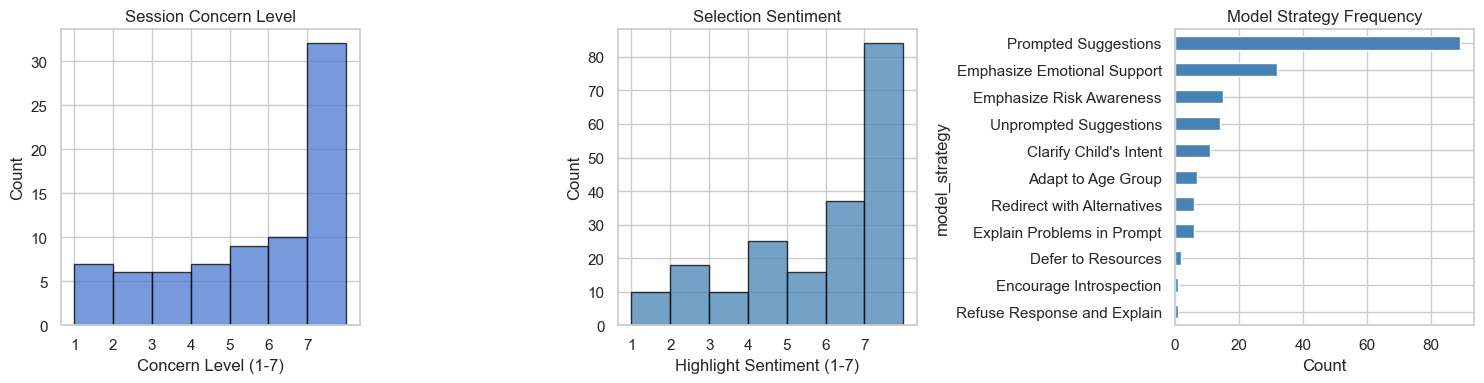

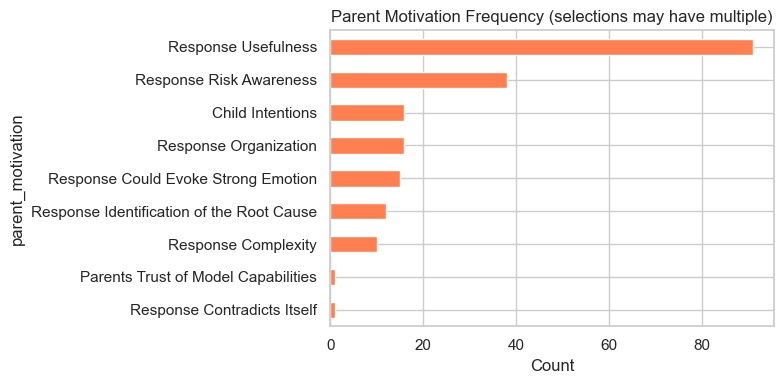


Model strategy counts:


,count,pct
model_strategy,,
Prompted Suggestions,89,48.4
Emphasize Emotional Support,32,17.4
Emphasize Risk Awareness,15,8.2
Unprompted Suggestions,14,7.6
Clarify Child's Intent,11,6.0
Adapt to Age Group,7,3.8
Redirect with Alternatives,6,3.3
Explain Problems in Prompt,6,3.3
Defer to Resources,2,1.1



Parent motivation counts (exploded):


,count,pct
parent_motivation,,
Response Usefulness,91,45.5
Response Risk Awareness,38,19.0
Child Intentions,16,8.0
Response Organization,16,8.0
Response Could Evoke Strong Emotion,15,7.5
Response Identification of the Root Cause,12,6.0
Response Complexity,10,5.0
Parents Trust of Model Capabilities,1,0.5
Response Contradicts Itself,1,0.5


In [11]:
print("=" * 60)
print("SESSION LEVEL (df_session)")
print("=" * 60)
print(f"Sessions:  {len(df_session)}")
print(f"Parents:   {df_session['user_id'].nunique()}")
print(f"Scenarios: {df_session['scenario_id'].nunique()}")
cl = df_session["concern_level"].dropna()
print(f"concern_level: mean={cl.mean():.2f}, SD={cl.std():.2f}, range=[{cl.min()},{cl.max()}]")
rl = df_session["realism_level"].dropna()
print(f"realism_level: mean={rl.mean():.2f}, SD={rl.std():.2f}")

print("\n" + "=" * 60)
print("SELECTION LEVEL (df_sel)")
print("=" * 60)
print(f"Selections:        {len(df_sel)}")
print(f"highlight_sentiment: mean={df_sel['highlight_sentiment'].mean():.2f}, "
      f"SD={df_sel['highlight_sentiment'].std():.2f}")
print(f"Selections per parent-scenario: "
      f"mean={df_sel.groupby(['parent_id','scenario_id']).size().mean():.1f}")
pct_multi = (df_sel["parent_motivation"].str.contains(" | ", regex=False, na=False)).mean()
print(f"Selections with multiple parent motivations: {pct_multi:.0%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# concern_level distribution
axes[0].hist(cl, bins=range(1, 9), edgecolor="black", alpha=0.75)
axes[0].set_xlabel("Concern Level (1-7)"); axes[0].set_ylabel("Count")
axes[0].set_title("Session Concern Level"); axes[0].set_xticks(range(1, 8))

# highlight_sentiment distribution
hs = df_sel["highlight_sentiment"].dropna()
axes[1].hist(hs, bins=range(1, 9), edgecolor="black", alpha=0.75, color="steelblue")
axes[1].set_xlabel("Highlight Sentiment (1-7)"); axes[1].set_ylabel("Count")
axes[1].set_title("Selection Sentiment"); axes[1].set_xticks(range(1, 8))

# model_strategy frequency
ms_freq = df_sel["model_strategy"].value_counts()
ms_freq.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Model Strategy Frequency")
axes[2].set_xlabel("Count"); axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "descriptives.png"), dpi=150, bbox_inches="tight")
plt.show()

# parent_motivation frequency (exploded)
pm_freq = explode_codes(df_sel, "parent_motivation")["parent_motivation"].value_counts()
fig, ax = plt.subplots(figsize=(8, max(4, len(pm_freq) * 0.4)))
pm_freq.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Parent Motivation Frequency (selections may have multiple)")
ax.set_xlabel("Count"); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "parent_motivation_freq.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nModel strategy counts:")
display(ms_freq.to_frame("count").assign(pct=lambda d: (d["count"]/d["count"].sum()*100).round(1)))
print("\nParent motivation counts (exploded):")
display(pm_freq.to_frame("count").assign(pct=lambda d: (d["count"]/len(df_sel)*100).round(1)))

## Part 1: Model Strategy

What model behaviors did parents highlight, and how do they vary by scenario context?

=== Model Strategy by Context ===

domain: chi2=52.96, df=20, p=0.000


domain,Academic Domain,Casual Knowledge Domain,Relationship Domain
model_strategy,,,
Adapt to Age Group,0,7,0
Clarify Child's Intent,1,7,3
Defer to Resources,0,2,0
Emphasize Emotional Support,2,19,11
Emphasize Risk Awareness,0,8,7
Encourage Introspection,0,0,1
Explain Problems in Prompt,1,3,2
Prompted Suggestions,20,56,13
Redirect with Alternatives,5,1,0



age_band: chi2=57.64, df=30, p=0.002


age_band,13-15,16-18,6-8,9-12
model_strategy,,,,
Adapt to Age Group,0,2,1,4
Clarify Child's Intent,5,3,3,0
Defer to Resources,0,0,0,2
Emphasize Emotional Support,17,4,4,7
Emphasize Risk Awareness,2,9,0,4
Encourage Introspection,1,0,0,0
Explain Problems in Prompt,5,0,0,1
Prompted Suggestions,23,24,13,29
Redirect with Alternatives,5,0,0,1



sensitivity_level: chi2=60.35, df=20, p=0.000


sensitivity_level,available,intimate,sensitive
model_strategy,,,
Adapt to Age Group,7,0,0
Clarify Child's Intent,1,3,7
Defer to Resources,0,0,2
Emphasize Emotional Support,6,6,20
Emphasize Risk Awareness,1,1,13
Encourage Introspection,0,0,1
Explain Problems in Prompt,1,0,5
Prompted Suggestions,49,6,34
Redirect with Alternatives,5,0,1


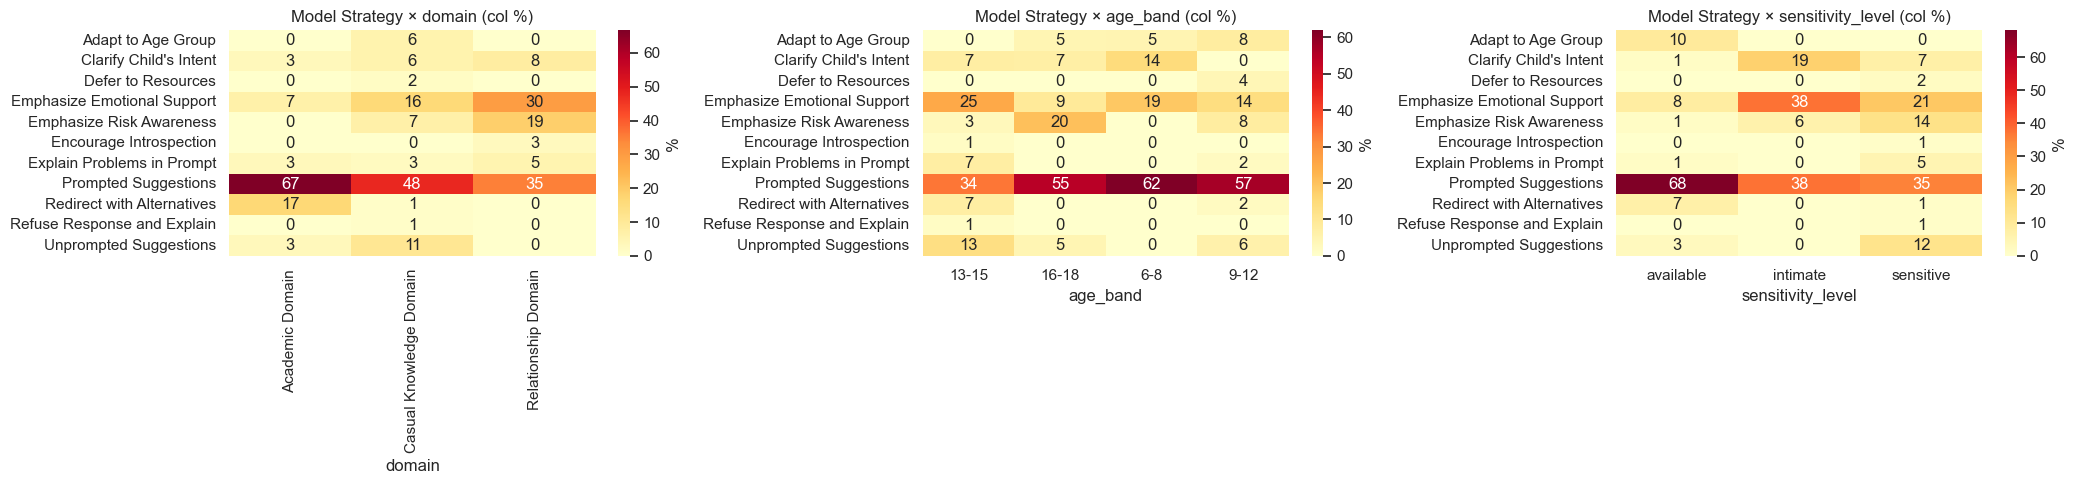


--- Per-code logistic (codes ≥5% prevalence) ---


In [12]:
# 1a: Model Strategy by Context
print("=== Model Strategy by Context ===")
_ms_df = df_sel[df_sel["model_strategy"].notna()].copy()

context_vars = [v for v in ["domain","age_band","sensitivity_level"] if v in _ms_df.columns]
for var in context_vars:
    ct = pd.crosstab(_ms_df["model_strategy"], _ms_df[var])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"\n{var}: chi2={chi2:.2f}, df={dof}, p={p:.3f}")
    display(ct)

# Heatmaps
fig, axes = plt.subplots(1, len(context_vars), figsize=(7 * len(context_vars), max(5, _ms_df["model_strategy"].nunique() * 0.45)))
if len(context_vars) == 1: axes = [axes]
for ax, var in zip(axes, context_vars):
    ct_pct = pd.crosstab(_ms_df["model_strategy"], _ms_df[var], normalize="columns") * 100
    sns.heatmap(ct_pct, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "%"})
    ax.set_title(f"Model Strategy × {var} (col %)")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_strategy_by_context.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-code logistic regression
print("\n--- Per-code logistic (codes ≥5% prevalence) ---")
_usable = [f for f in ["domain","age_band","sensitivity_level"] if f in _ms_df.columns
           and _ms_df[f].nunique() > 1]
_ms_codes = prevalence_codes(_ms_df["model_strategy"], sep=None)
for code in _ms_codes.index:
    _ms_df[f"_y"] = (_ms_df["model_strategy"] == code).astype(int)
    if _ms_df["_y"].sum() < 5: continue
    formula = "_y ~ " + " + ".join(f"C({f}, Treatment(reference='{REFERENCE_LEVELS.get(f, '')}'))" for f in _usable)
    res = fit_mixed_or_fallback(formula, _ms_df, "parent_id", family="binomial", verbose=False)
    if res["converged"]:
        tbl = res["model"].params.to_frame("coef").join(res["model"].pvalues.to_frame("p"))
        tbl["OR"] = np.exp(tbl["coef"]).round(2)
        sig = tbl[tbl["p"] < ALPHA].drop(index=[i for i in tbl.index if "Intercept" in str(i)], errors='ignore')
        if not sig.empty:
            print(f"\n{code}:")
            display(sig[["OR","p"]].round(3))

=== Model Strategy × Highlight Sentiment ===


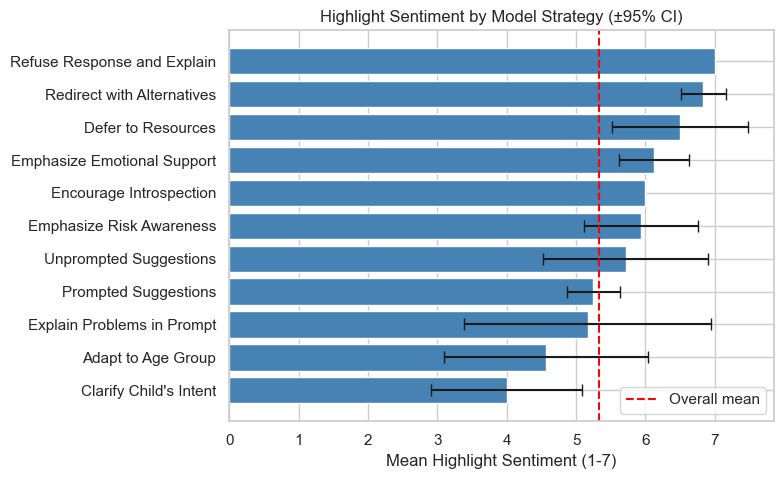

,mean,sem,count
model_strategy,,,
Refuse Response and Explain,7.00,NaN,1
Redirect with Alternatives,6.83,0.17,6
Defer to Resources,6.50,0.50,2
Emphasize Emotional Support,6.12,0.26,32
Encourage Introspection,6.00,NaN,1
Emphasize Risk Awareness,5.93,0.42,15
Unprompted Suggestions,5.71,0.61,14
Prompted Suggestions,5.25,0.19,89
Explain Problems in Prompt,5.17,0.91,6



Mixed model (mixed):


,coef,p
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Clarify Child's Intent]",-0.550,0.236
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Defer to Resources]",0.147,0.879
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Emotional Support]",0.549,0.096
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Risk Awareness]",0.514,0.207
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Encourage Introspection]",0.339,0.813
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Explain Problems in Prompt]",0.378,0.536
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Redirect with Alternatives]",0.837,0.228
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Refuse Response and Explain]",1.618,0.242
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Unprompted Suggestions]",0.598,0.164


In [13]:
# 1b: Model Strategy × Sentiment
print("=== Model Strategy × Highlight Sentiment ===")
_ms_s = df_sel[df_sel["model_strategy"].notna() & df_sel["highlight_sentiment"].notna()].copy()

_means = _ms_s.groupby("model_strategy")["highlight_sentiment"].agg(["mean","sem","count"])
_means = _means.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(_means) * 0.45)))
ax.barh(_means.index, _means["mean"], xerr=1.96*_means["sem"], color="steelblue", capsize=4)
ax.axvline(df_sel["highlight_sentiment"].mean(), color="red", linestyle="--", label="Overall mean")
ax.set_xlabel("Mean Highlight Sentiment (1-7)")
ax.set_title("Highlight Sentiment by Model Strategy (±95% CI)")
ax.invert_yaxis(); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_strategy_sentiment.png"), dpi=150, bbox_inches="tight")
plt.show()
display(_means.round(2))

# Mixed model
_ms_s["model_strategy_cat"] = _ms_s["model_strategy"].astype("category")
_ref_ms = _ms_s["model_strategy"].value_counts().idxmax()
formula_ms = f"highlight_sentiment ~ C(model_strategy, Treatment(reference='{_ref_ms}'))"
res_ms = fit_mixed_or_fallback(formula_ms, _ms_s, "parent_id")
if res_ms["converged"]:
    print(f"\nMixed model ({res_ms['model_type']}):")
    tbl = res_ms["model"].params.to_frame("coef").join(res_ms["model"].pvalues.to_frame("p"))
    display(tbl[~tbl.index.str.contains("Intercept|Group")].round(3))

## Part 2: Parent Motivation

What motivates parents to flag selections, and how does this vary by context?

=== Parent Motivation by Context ===

domain: chi2=93.35, df=16, p=0.000

age_band: chi2=63.31, df=24, p=0.000

sensitivity_level: chi2=36.69, df=16, p=0.002


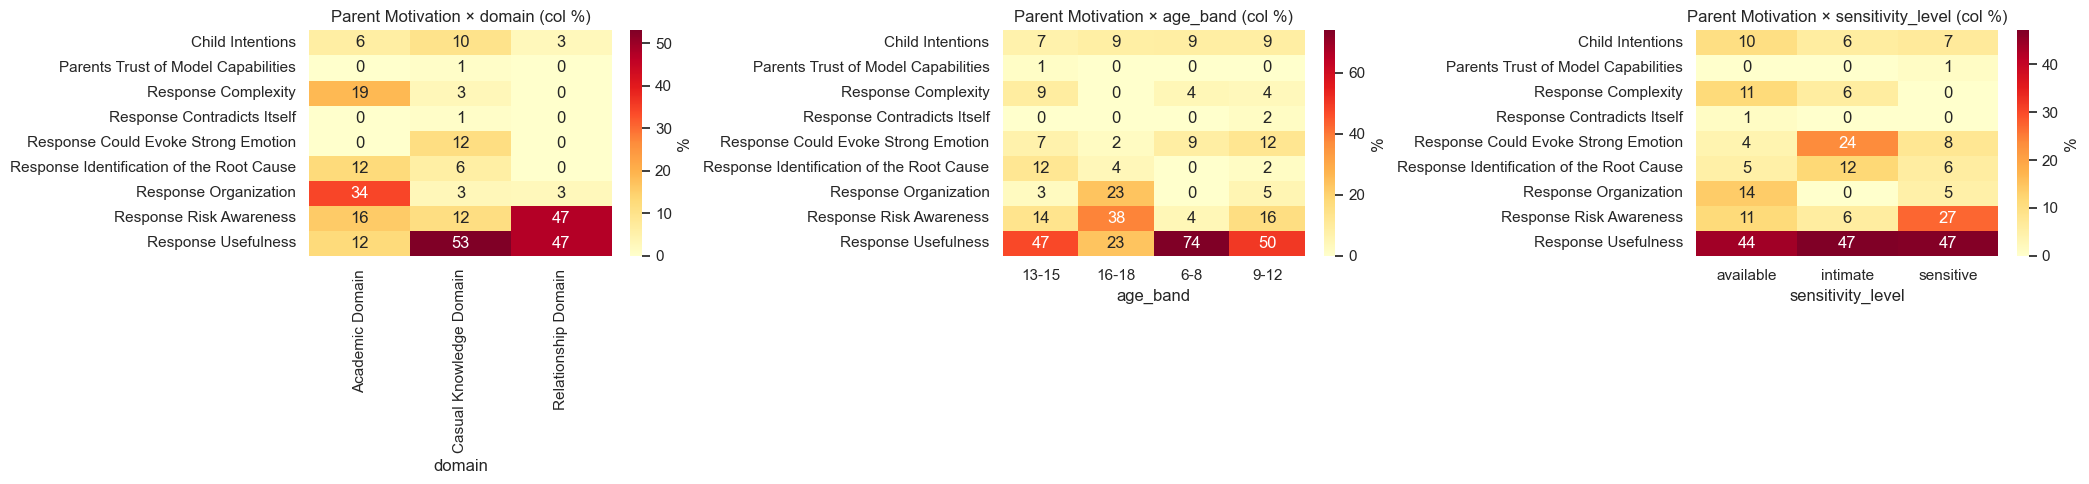


--- Per-code logistic (codes ≥5% prevalence) ---

Response Usefulness:


,OR,p
"C(domain, Treatment(reference='Casual Knowledge Domain'))[T.Academic Domain]",0.1,0.04



Response Risk Awareness:


,OR,p
"C(domain, Treatment(reference='Casual Knowledge Domain'))[T.Relationship Domain]",4.96,0.008



Response Organization:


...

,OR,p
"C(domain, Treatment(reference='Casual Knowledge Domain'))[T.Academic Domain]",0.0,0.0
"C(domain, Treatment(reference='Casual Knowledge Domain'))[T.Relationship Domain]",0.0,0.0



Response Identification of the Root Cause:


,OR,p
"C(domain, Treatment(reference='Casual Knowledge Domain'))[T.Relationship Domain]",0.0,0.0
"C(age_band, Treatment(reference='9-12'))[T.6-8]",0.0,0.0



Response Complexity:


,OR,p
"C(domain, Treatment(reference='Casual Knowledge Domain'))[T.Relationship Domain]",0.0,0.0
"C(age_band, Treatment(reference='9-12'))[T.16-18]",0.0,0.0


In [14]:
# 2a: Parent Motivation by Context (explode multiselect)
print("=== Parent Motivation by Context ===")
_pm_long = explode_codes(df_sel[df_sel["parent_motivation"].notna()], "parent_motivation")

context_vars = [v for v in ["domain","age_band","sensitivity_level"] if v in _pm_long.columns]
for var in context_vars:
    ct = pd.crosstab(_pm_long["parent_motivation"], _pm_long[var])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"\n{var}: chi2={chi2:.2f}, df={dof}, p={p:.3f}")

# Heatmaps
fig, axes = plt.subplots(1, len(context_vars), figsize=(7*len(context_vars), max(5, _pm_long["parent_motivation"].nunique()*0.45)))
if len(context_vars) == 1: axes = [axes]
for ax, var in zip(axes, context_vars):
    ct_pct = pd.crosstab(_pm_long["parent_motivation"], _pm_long[var], normalize="columns") * 100
    sns.heatmap(ct_pct, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label":"%"})
    ax.set_title(f"Parent Motivation × {var} (col %)")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "parent_motivation_by_context.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-code logistic
print("\n--- Per-code logistic (codes ≥5% prevalence) ---")
_usable = [f for f in ["domain","age_band","sensitivity_level"] if f in df_sel.columns
           and df_sel[f].nunique() > 1]
_pm_codes = prevalence_codes(df_sel["parent_motivation"])
for code in _pm_codes.index:
    df_sel[f"_pm_y"] = df_sel["parent_motivation"].fillna("").str.contains(
        re.escape(code)).astype(int)
    if df_sel["_pm_y"].sum() < 5: continue
    _tmp = df_sel[df_sel["parent_motivation"].notna()].copy()
    formula = "_pm_y ~ " + " + ".join(f"C({f}, Treatment(reference='{REFERENCE_LEVELS.get(f,'')}'))" for f in _usable)
    res = fit_mixed_or_fallback(formula, _tmp, "parent_id", family="binomial", verbose=False)
    if res["converged"]:
        tbl = res["model"].params.to_frame("coef").join(res["model"].pvalues.to_frame("p"))
        tbl["OR"] = np.exp(tbl["coef"]).round(2)
        sig = tbl[tbl["p"] < ALPHA].drop(index=[i for i in tbl.index if "Intercept" in str(i)], errors='ignore')
        if not sig.empty:
            print(f"\n{code}:")
            display(sig[["OR","p"]].round(3))

=== Parent Motivation × Highlight Sentiment ===


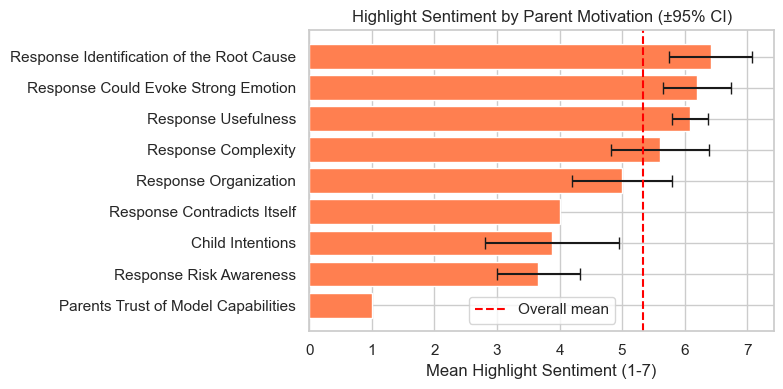

,mean,sem,count
parent_motivation,,,
Response Identification of the Root Cause,6.42,0.34,12
Response Could Evoke Strong Emotion,6.20,0.28,15
Response Usefulness,6.09,0.15,91
Response Complexity,5.60,0.40,10
Response Organization,5.00,0.41,16
Response Contradicts Itself,4.00,NaN,1
Child Intentions,3.88,0.55,16
Response Risk Awareness,3.66,0.34,38
Parents Trust of Model Capabilities,1.00,NaN,1


In [15]:
# 2b: Parent Motivation × Sentiment
print("=== Parent Motivation × Highlight Sentiment ===")
_pm_s = explode_codes(df_sel[df_sel["parent_motivation"].notna() & df_sel["highlight_sentiment"].notna()],
                      "parent_motivation")

_means_pm = _pm_s.groupby("parent_motivation")["highlight_sentiment"].agg(["mean","sem","count"])
_means_pm = _means_pm.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(_means_pm)*0.45)))
ax.barh(_means_pm.index, _means_pm["mean"], xerr=1.96*_means_pm["sem"], color="coral", capsize=4)
ax.axvline(df_sel["highlight_sentiment"].mean(), color="red", linestyle="--", label="Overall mean")
ax.set_xlabel("Mean Highlight Sentiment (1-7)")
ax.set_title("Highlight Sentiment by Parent Motivation (±95% CI)")
ax.invert_yaxis(); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "parent_motivation_sentiment.png"), dpi=150, bbox_inches="tight")
plt.show()
display(_means_pm.round(2))

## Part 3: Model Strategy × Parent Motivation

Do certain model behaviors predict what motivates parents to flag them?

=== Model Strategy × Parent Motivation ===
Chi-square: chi2=92.66, df=70, p=0.0363


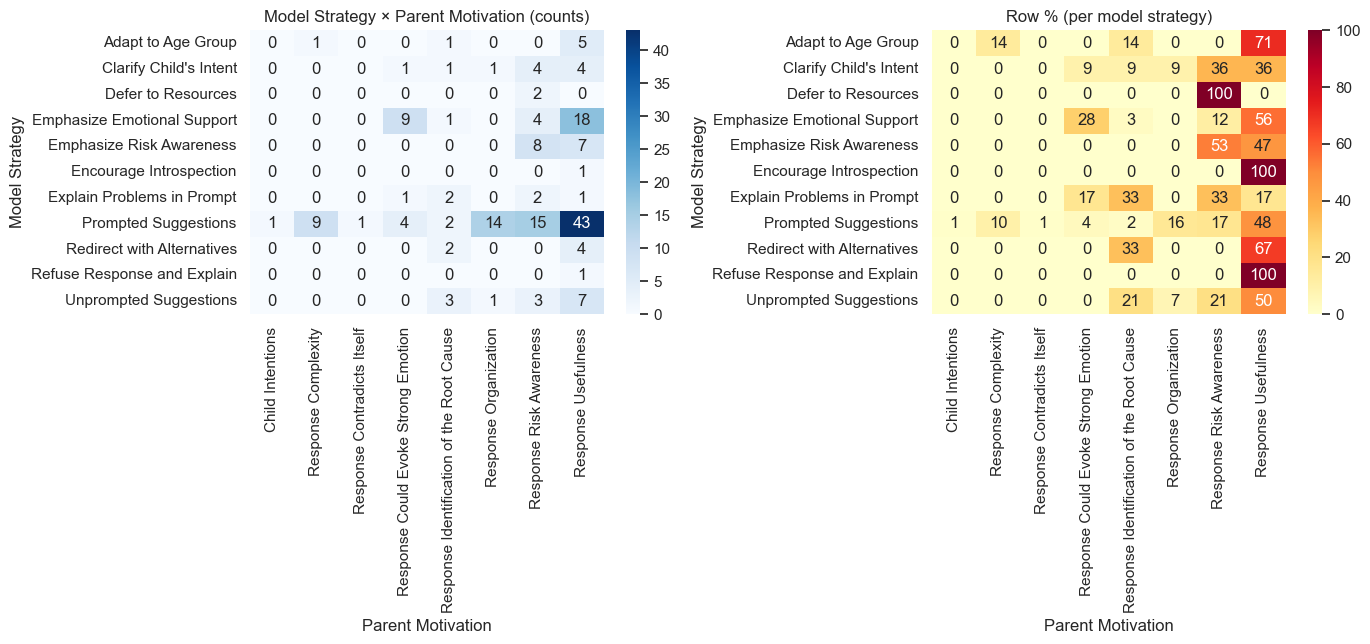

In [16]:
# 3a: Co-occurrence crosstab
print("=== Model Strategy × Parent Motivation ===")
_both = df_sel[df_sel["model_strategy"].notna() & df_sel["parent_motivation"].notna()].copy()
_both_long = explode_codes(_both, "parent_motivation")

ct = pd.crosstab(_both_long["model_strategy"], _both_long["parent_motivation"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square: chi2={chi2:.2f}, df={dof}, p={p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(max(14, ct.shape[1]*1.3), max(6, ct.shape[0]*0.6)))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Model Strategy × Parent Motivation (counts)")
sns.heatmap(ct_pct.round(0), annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Row % (per model strategy)")
for ax in axes: ax.set_ylabel("Model Strategy"); ax.set_xlabel("Parent Motivation")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "strategy_x_motivation_crosstab.png"), dpi=150, bbox_inches="tight")
plt.show()

ct.to_csv(os.path.join(OUTPUT_DIR, "strategy_x_motivation_crosstab.csv"))
ct_pct.round(1).to_csv(os.path.join(OUTPUT_DIR, "strategy_x_motivation_crosstab_pct.csv"))

In [17]:
# 3b: Does model_strategy predict parent_motivation?
print("=== Logistic: P(motivation = X) ~ model_strategy ===")
_pm_codes = prevalence_codes(df_sel["parent_motivation"])
_ref_ms = df_sel["model_strategy"].value_counts().idxmax()

for code in _pm_codes.index:
    _tmp = df_sel[df_sel["model_strategy"].notna() & df_sel["parent_motivation"].notna()].copy()
    _tmp["_y"] = _tmp["parent_motivation"].str.contains(re.escape(code)).astype(int)
    if _tmp["_y"].sum() < 5: continue
    formula = f"_y ~ C(model_strategy, Treatment(reference='{_ref_ms}'))"
    res = fit_mixed_or_fallback(formula, _tmp, "parent_id", family="binomial", verbose=False)
    if res["converged"]:
        tbl = res["model"].params.to_frame("coef").join(res["model"].pvalues.to_frame("p"))
        tbl["OR"] = np.exp(tbl["coef"]).round(2)
        sig = tbl[tbl["p"] < ALPHA].drop(index=[i for i in tbl.index if "Intercept" in str(i)], errors='ignore')
        if not sig.empty:
            print(f"\nMotivation: {code}")
            display(sig[["OR","p"]].round(3))

=== Logistic: P(motivation = X) ~ model_strategy ===

Motivation: Response Usefulness


,OR,p
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Defer to Resources]",0.000000e+00,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Encourage Introspection]",1.836127e+10,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Refuse Response and Explain]",1.836127e+10,0.0



Motivation: Response Risk Awareness


,OR,p
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Adapt to Age Group]",0.000000e+00,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Defer to Resources]",2.301693e+11,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Risk Awareness]",5.640000e+00,0.016
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Encourage Introspection]",0.000000e+00,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Redirect with Alternatives]",0.000000e+00,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Refuse Response and Explain]",0.000000e+00,0.000



Motivation: Response Organization


...

,OR,p
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Adapt to Age Group]",0.00,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Defer to Resources]",0.00,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Emotional Support]",8.32,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Risk Awareness]",0.00,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Encourage Introspection]",0.00,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Redirect with Alternatives]",0.00,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Refuse Response and Explain]",0.00,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Unprompted Suggestions]",0.00,0.0



Motivation: Response Identification of the Root Cause


,OR,p
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Adapt to Age Group]",7.25,0.005
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Defer to Resources]",0.00,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Risk Awareness]",0.00,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Encourage Introspection]",0.00,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Explain Problems in Prompt]",21.75,0.027
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Redirect with Alternatives]",21.75,0.001
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Refuse Response and Explain]",0.00,0.000
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Unprompted Suggestions]",11.86,0.013



Motivation: Response Complexity


,OR,p
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Clarify Child's Intent]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Defer to Resources]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Emotional Support]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Emphasize Risk Awareness]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Encourage Introspection]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Explain Problems in Prompt]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Redirect with Alternatives]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Refuse Response and Explain]",0.0,0.0
"C(model_strategy, Treatment(reference='Prompted Suggestions'))[T.Unprompted Suggestions]",0.0,0.0


## Part 4: Context Effects on Concern Intensity

Do scenario characteristics predict how positively or negatively parents rate highlighted text?

In [18]:
# 4a: Session-level concern_level ~ scenario factors
print("=== Session-Level: concern_level ~ scenario factors ===")
_usable = [f for f in SCENARIO_FACTORS if f in df_session.columns
           and df_session[f].nunique() > 1]

_mdf = df_session[["concern_level","user_id","scenario_id"] + _usable].dropna(subset=["concern_level"])

# Null model (ICC)
try:
    _null = mixedlm("concern_level ~ 1", _mdf, groups=_mdf["user_id"]).fit(reml=True, maxiter=200)
    _var_between = float(_null.cov_re.iloc[0,0])
    _var_total = _var_between + _null.scale
    print(f"ICC (parent random intercept): {_var_between/_var_total:.3f}")
except Exception as e:
    print(f"Null model failed: {e}")

# Main effects model
_formula_main = "concern_level ~ " + " + ".join(
    f"C({f}, Treatment(reference='{REFERENCE_LEVELS.get(f,'')}'))" for f in _usable)
res_session = fit_mixed_or_fallback(_formula_main, _mdf, "user_id")
if res_session["converged"]:
    print(f"\nMain effects model ({res_session['model_type']}):")
    tbl = res_session["model"].params.to_frame("coef").join(res_session["model"].pvalues.to_frame("p"))
    sig = tbl[tbl["p"] < ALPHA].drop(index=[i for i in tbl.index if "Intercept" in str(i)], errors='ignore')
    display(sig.round(3) if not sig.empty else pd.DataFrame({"result": ["No significant factors"]}))

=== Session-Level: concern_level ~ scenario factors ===
ICC (parent random intercept): 0.319
Mixed model failed (specified level '' not found), falling back to OLS.
OLS fallback also failed: specified level '' not found


In [19]:
# 4b: Selection-level highlight_sentiment ~ scenario factors
print("=== Selection-Level: highlight_sentiment ~ scenario factors ===")
_usable_sel = [f for f in SCENARIO_FACTORS if f in df_sel.columns
               and df_sel[f].nunique() > 1]
_sel_mdf = df_sel[["highlight_sentiment","parent_id","scenario_id"] + _usable_sel].dropna(subset=["highlight_sentiment"])

_formula_sel = "highlight_sentiment ~ " + " + ".join(
    f"C({f}, Treatment(reference='{REFERENCE_LEVELS.get(f,'')}'))" for f in _usable_sel)
res_sel = fit_mixed_or_fallback(_formula_sel, _sel_mdf, "parent_id")
if res_sel["converged"]:
    print(f"Selection-level model ({res_sel['model_type']}):")
    tbl = res_sel["model"].params.to_frame("coef").join(res_sel["model"].pvalues.to_frame("p"))
    sig = tbl[tbl["p"] < ALPHA].drop(index=[i for i in tbl.index if "Intercept" in str(i)], errors='ignore')
    display(sig.round(3) if not sig.empty else pd.DataFrame({"result": ["No significant factors"]}))

=== Selection-Level: highlight_sentiment ~ scenario factors ===
Mixed model failed (specified level '' not found), falling back to OLS.
OLS fallback also failed: specified level '' not found


## Part 5: Realism Invariance

Does scenario realism confound concern ratings?

In [20]:
# 5: Realism invariance + TOST
rl = df_session["realism_level"].dropna()
print(f"Realism: mean={rl.mean():.2f}, SD={rl.std():.2f}, range=[{rl.min()},{rl.max()}]")
print(f"Prop ≥4: {(rl>=4).mean():.0%} | Prop ≤3: {(rl<=3).mean():.0%}")

_rm = df_session[["concern_level","realism_centered","user_id"]].dropna()
res_real = fit_mixed_or_fallback("concern_level ~ realism_centered", _rm, "user_id")
if res_real["converged"]:
    coef = res_real["model"].params.get("realism_centered", np.nan)
    pval = res_real["model"].pvalues.get("realism_centered", np.nan)
    print(f"\nRealism effect: coef={coef:.3f}, p={pval:.3f}")

# TOST equivalence test on Pearson r
_r, _p = stats.pearsonr(_rm["concern_level"], _rm["realism_centered"])
n_tost = len(_rm)
_se = 1 / np.sqrt(n_tost - 3)
_z = np.arctanh(_r)
_bound = np.arctanh(EQUIVALENCE_BOUND)
_p_low  = 1 - stats.norm.cdf((_z - (-_bound)) / _se)  # H0: r ≤ -bound
_p_high = stats.norm.cdf((_z - _bound) / _se)           # H0: r ≥ +bound
_p_tost = max(_p_low, _p_high)
print(f"\nPearson r={_r:.3f} (p={_p:.3f})")
print(f"TOST (bound=±{EQUIVALENCE_BOUND}): p={_p_tost:.3f}")
print("→ Realism effect is NEGLIGIBLE" if _p_tost < ALPHA else "→ Cannot confirm negligible realism effect")

Realism: mean=5.82, SD=1.35, range=[2.0,7.0]
Prop ≥4: 91% | Prop ≤3: 9%



Realism effect: coef=0.288, p=0.110

Pearson r=0.244 (p=0.033)
TOST (bound=±0.5): p=0.005
→ Realism effect is NEGLIGIBLE


## Export Results

In [21]:
# Save df_sel and frequency tables
df_sel.to_csv(os.path.join(OUTPUT_DIR, "df_sel.csv"), index=False)

ms_freq = df_sel["model_strategy"].value_counts().to_frame("count")
ms_freq["pct"] = (ms_freq["count"] / len(df_sel) * 100).round(1)
ms_freq.to_csv(os.path.join(OUTPUT_DIR, "model_strategy_freq.csv"))

pm_freq = explode_codes(df_sel, "parent_motivation")["parent_motivation"].value_counts().to_frame("count")
pm_freq["pct_of_selections"] = (pm_freq["count"] / len(df_sel) * 100).round(1)
pm_freq.to_csv(os.path.join(OUTPUT_DIR, "parent_motivation_freq.csv"))

# Summary text
with open(os.path.join(OUTPUT_DIR, "highlight_analysis_summary.txt"), "w") as f:
    f.write(f"Highlight Analysis Summary\n")
    f.write(f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d')}\n")
    f.write(f"Export timestamp: {EXPORT_TIMESTAMP}\n\n")
    f.write(f"Sessions:   {len(df_session)}\n")
    f.write(f"Parents:    {df_session['user_id'].nunique()}\n")
    f.write(f"Scenarios:  {df_session['scenario_id'].nunique()}\n")
    f.write(f"Selections: {len(df_sel)}\n")
    f.write(f"model_strategy coded:    {df_sel['model_strategy'].notna().sum()}\n")
    f.write(f"parent_motivation coded: {df_sel['parent_motivation'].notna().sum()}\n")

print(f"Results saved to: {OUTPUT_DIR}")
print(f"  df_sel.csv ({len(df_sel)} rows)")
print(f"  model_strategy_freq.csv")
print(f"  parent_motivation_freq.csv")
print(f"  strategy_x_motivation_crosstab.csv")
print(f"  highlight_analysis_summary.txt")

Results saved to: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260412_183830/highlight_analysis_output


  df_sel.csv (200 rows)
  model_strategy_freq.csv
  parent_motivation_freq.csv
  strategy_x_motivation_crosstab.csv
  highlight_analysis_summary.txt
